In [4]:
import os
from architecture import ConvNetPooling, nn
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder, EMNIST
import torchvision.transforms as transforms
import json
import numpy as np
from sklearn.metrics import confusion_matrix

dir_path = os.path.abspath('')
models_folder = os.path.join(dir_path, 'model')

device = torch.device("cuda")
batch_size = 32
cur_path = os.path.abspath('')
test_path = os.path.join(dir_path, 'data', 'test')
save_path = os.path.join(dir_path, 'model', 'training_pyramid0', 'cnn_-8_12_12_best.pth')
to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), transforms.ToTensor()
])
dataset = EMNIST(root="data_emnist", split="letters", train=False, transform=to_tensor)
labels = [label for _, label in dataset]
output_size = len(set(labels))
sample_image, _ = dataset[0]
_, width, height = list(sample_image.shape)
testloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

label_mapping = [chr(ord('a') + i) for i in range(0, 26)]


def load_model(folder, no):
    metadata_path = os.path.join(models_folder, folder, "train_metadata" + str(no) + ".json")
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    model = ConvNetPooling(height=height, width=width, output=output_size, channels=metadata['channels'])
    model_path = os.path.join(models_folder, folder, "cnn" + str(no) + '.pth')
    model.load_state_dict(torch.load(model_path, weights_only=True))
    return model

folder = "training_pyramid11"
no = 25
conv_net = load_model(folder, no)

from train import validation
d = validation(conv_net, testloader, save_folder=None)
predicted = d['predicted']
expected = d['expected']

cm = confusion_matrix(expected, predicted)

c:\Users\mokrota\Documents\GitHub\Neural-Network-Project\.venv\Lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


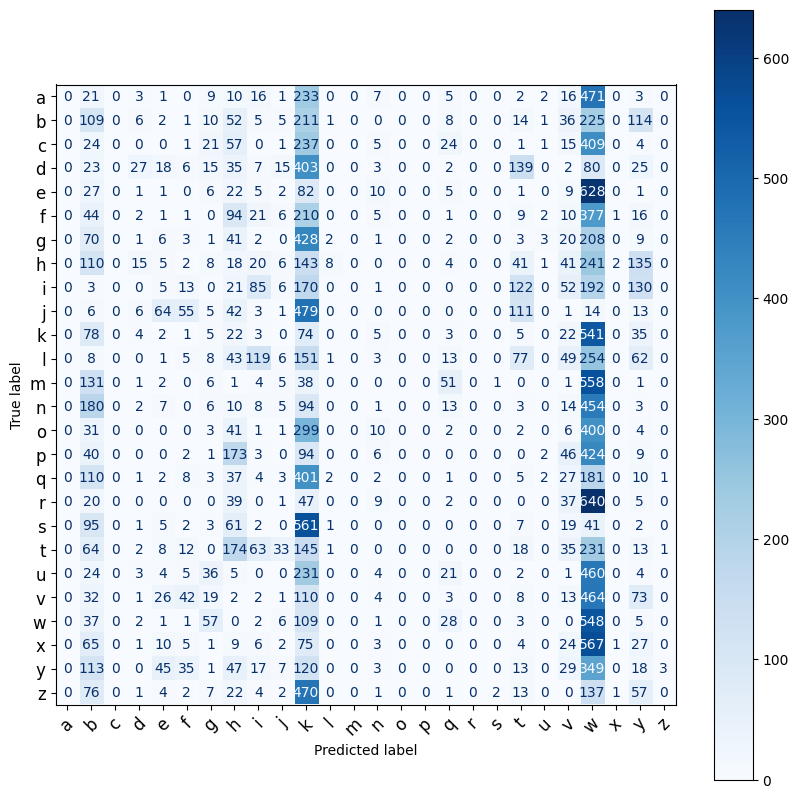

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[chr(ord('a') + i) for i in range(26)])
disp.plot(ax=ax, cmap="Blues", values_format='d')

plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.show()


In [13]:
correct = cm.diagonal().sum()
print(correct)

918


In [14]:
total = cm.sum()
print(total)

20800


In [15]:
print(correct / total)

0.04413461538461538
